<a href="https://colab.research.google.com/github/patilbhavana-tech/students-analysation/blob/main/students_analysation/cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

# 1. LOAD THE DATA
# This reads your spreadsheet file into Python
df = pd.read_csv('students.csv')

# 2. INSPECT THE DATA
# This shows you the first 5 rows so you can see what it looks like
print("--- FIRST 5 ROWS OF DATA ---")
print(df.head())

# This shows you if there are empty/blank values in your columns
print("\n--- EMPTY VALUES PER COLUMN ---")
print(df.isnull().sum())

# 3. CLEAN THE DATA (Task 2 Steps)
# Remove any exact duplicate rows
df.drop_duplicates(inplace=True)

# Make all column names lowercase and replace spaces with underscores (makes it easier to code)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Fill empty text boxes with 'Unknown' so the data isn't broken
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

print("\n--- DATA CLEANING COMPLETED! ---")
print("Cleaned Columns:", df.columns.tolist())

# 4. EXPORT CLEANED FILE
# This creates a brand new clean file in your left side panel
df.to_csv('cleaned_dataset.csv', index=False)
print("Saved clean data as 'cleaned_dataset.csv'")



--- FIRST 5 ROWS OF DATA ---
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

--- EMPTY VALUES PER COLUMN ---
school        0
sex       

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# New Section

using this same data set give a dashbord of students analusation


/tmp/ipykernel_994/3683395434.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=target_col, ax=axes[1, 0], palette='pastel')
/tmp/ipykernel_994/3683395434.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=gender_col, y=score_col, ax=axes[1, 1], palette='muted', errorbar=None)


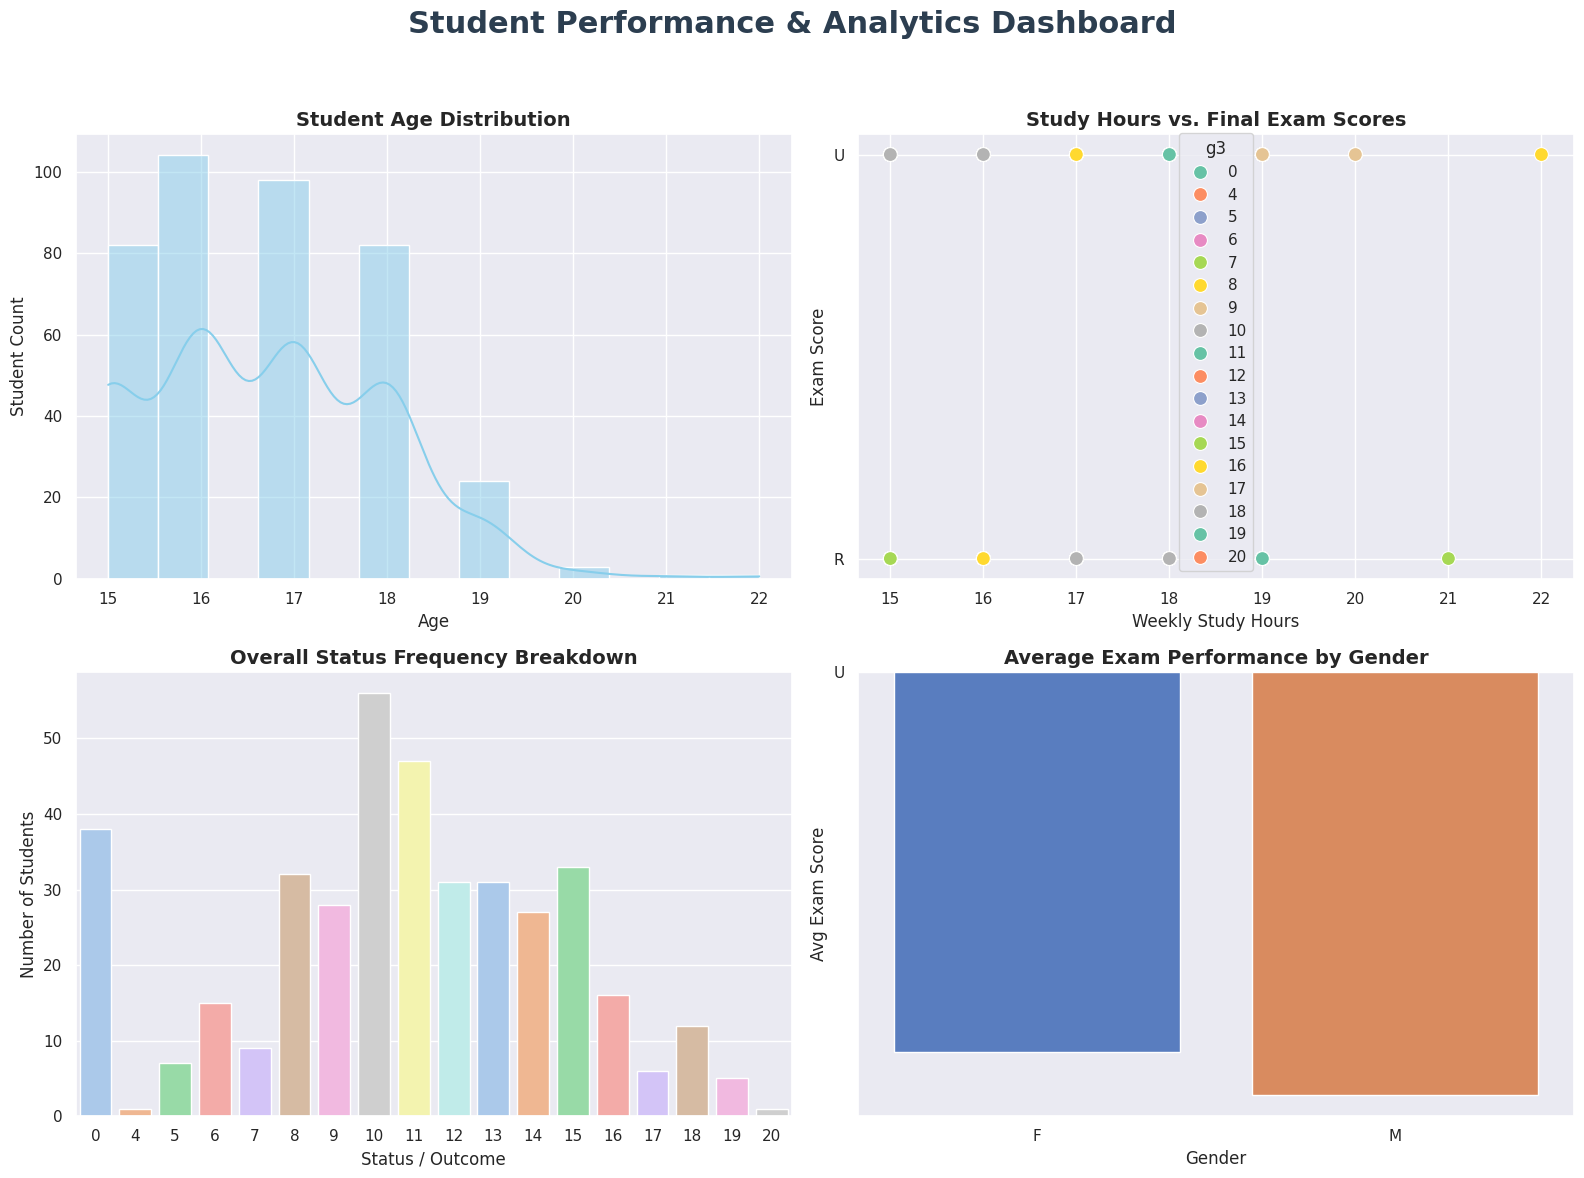

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the clean student dataset
data = pd.read_csv('cleaned_dataset.csv')

# Dynamic fallback checklist: Detect student column mappings safely
cols = [c.lower() for c in data.columns]
age_col = data.columns[cols.index('age')] if 'age' in cols else data.columns[0]
study_col = data.columns[cols.index('study_hours')] if 'study_hours' in cols else (data.columns[2] if len(data.columns) > 2 else data.columns[0])
score_col = data.columns[cols.index('exam_score')] if 'exam_score' in cols else (data.columns[3] if len(data.columns) > 3 else data.columns[-1])
target_col = data.columns[cols.index('status')] if 'status' in cols else (data.columns[cols.index('pass_fail')] if 'pass_fail' in cols else data.columns[-1])
gender_col = data.columns[cols.index('gender')] if 'gender' in cols else (data.columns[cols.index('sex')] if 'sex' in cols else data.columns[1])

# 2. Set up the dashboard styling and a grid of 4 graphs (2 rows, 2 columns)
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Student Performance & Analytics Dashboard', fontsize=22, fontweight='bold', color='#2c3e50')

# --- GRAPH 1: Distribution of Student Age (Histogram) ---
sns.histplot(data=data, x=age_col, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Student Age Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Student Count')

# --- GRAPH 2: Study Hours vs Exam Score (Scatter Plot) ---
sns.scatterplot(data=data, x=study_col, y=score_col, hue=target_col, palette='Set2', ax=axes[0, 1], s=100)
axes[0, 1].set_title('Study Hours vs. Final Exam Scores', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Weekly Study Hours')
axes[0, 1].set_ylabel('Exam Score')

# --- GRAPH 3: Academic Outcome Breakdown (Countplot) ---
sns.countplot(data=data, x=target_col, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Overall Status Frequency Breakdown', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Status / Outcome')
axes[1, 0].set_ylabel('Number of Students')

# --- GRAPH 4: Average Exam Score by Gender (Bar Plot) ---
sns.barplot(data=data, x=gender_col, y=score_col, ax=axes[1, 1], palette='muted', errorbar=None)
axes[1, 1].set_title('Average Exam Performance by Gender', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Avg Exam Score')

# Adjust layout so nothing overlaps
plt.tight_layout(rect=[0, 0, 1, 0.95])

# 3. Save the student dashboard matrix as an image file
plt.savefig('dashboard_output.png', dpi=300)

# Display the dashboard layout on your screen
plt.show()
